-*- encoding: utf-8 -*-
This file is part of GaPSE
Copyright (C) 2022 Matteo Foglieni
GaPSE is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.
GaPSE is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU
General Public License for more details.
You should have received a copy of the GNU General Public License
along with GaPSE. If not, see <http://www.gnu.org/licenses/>.

# sigma_i

The ``\sigma_i`` are the moments of the input matter Power Spectrum; they are defined as:

\begin{equation*}
  \sigma_i := \int_{k_\mathrm{min}}^{k_\mathrm{max}} \frac{\mathrm{d}q}{2\pi^2} \, q^{\,2-i} \, P(q) \; ,
\end{equation*}

and they are what every ``\Delta\chi \rightarrow 0`` limit of the TPCFs reduces to.
Unlike the ``I_\ell^n``, they depend explicitly on where the integral is cut, and
not all of them converge at the same rate: this script shows which ones are safe,
which ones are not, and where it makes sense to put the cut.

All the output files (plots and data) are saved in the `sigma_i/` directory.

In [1]:
"""
    help(x)

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.
"""
macro help(x)
    quote
        display("text/markdown", @doc $x)
    end
end;
@help @help

```julia
help(x)
```

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.


## GaPSE setup

In [2]:
# In case you prefer to use GaPSE in a Jupyter Notebook in a "distant" directory,
# you only have to set this path equal to the directory GaPSE is stored in.
#PATH_TO_GAPSE = "../"; 

In [3]:
using Pkg
Pkg.activate(@__DIR__)

# Rebuilt here when needed, so this runs on a fresh clone and under any Julia.
#  - GaPSE is NOT registered: only `Pkg.develop` can make it reachable.
#  - Project.toml = names + UUIDs, Julia-version INdependent, tracked by git.
#  - Manifest.toml = resolved versions, Julia-version specific, gitignored.
let THEORY_DEPS = ["Plots", "PyPlot", "LaTeXStrings", "QuadGK",
                   "DelimitedFiles", "Printf", "SpecialFunctions"]
    declared = collect(keys(Pkg.project().dependencies))
    id = Base.identify_package("GaPSE")
    if !("GaPSE" in declared) || isnothing(id) || isnothing(Base.locate_package(id))
        @info "theory/: making the GaPSE of this repository available"
        Pkg.develop(path = dirname(@__DIR__))
    end
    todo = filter(d -> !(d in declared), THEORY_DEPS)
    isempty(todo) || (@info "theory/: adding missing dependencies" todo; Pkg.add(todo))
    Pkg.resolve()       # Project.toml may declare more than the Manifest knows
    Pkg.instantiate()   # install it, resolved for THIS Julia
end

using GaPSE
using Plots, LaTeXStrings, QuadGK, DelimitedFiles, Printf

try
    pyplot()
catch err
    @warn "PyPlot cannot start (needs matplotlib); using GR instead"
    gr()
end

  Activating project at `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory`
     Project No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Project.toml`
    Manifest No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Manifest.toml`


Plots.PyPlotBackend()

In [4]:
const PATH_TO_GAPSE = normpath(joinpath(@__DIR__, ".."));
#include(PATH_TO_GAPSE * "src/GaPSE.jl");
# NOTE : do not run this cell multiple times! In you have a problem, restart
# the kernel an re-run all the cells.
# Input matter Power Spectrum P(q) at z=0
const FILE_PS = joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_pk.dat");

In [5]:
const DIR = joinpath(@__DIR__, "sigma_i");
@assert isdir(DIR) "ERROR: DIR=$DIR DOESN'T EXIST!!!"

In [6]:
const SAVE_TO_DOCS = true;
const DOCS_ASSETS = joinpath(PATH_TO_GAPSE, "docs", "src", "assets", "sigma_i");

# The `InputPS` extrapolates with a power law outside the range of the input file;
# these are the extremes of the tabulated data, i.e. the region where P(q) is
# actually *measured* and not extrapolated.
const PS_TABLE = readdlm(FILE_PS, comments=true);
const K_DATA_MIN, K_DATA_MAX = extrema(PS_TABLE[:, 1]);

# The three pairs of extremes that appear in GaPSE, and that we want to compare.
# - IPSTOOLS: the default `k_min`/`k_max` keywords of `IPSTools`, i.e. what the
#   stored `σ_i` are computed with, and therefore what every Δχ → 0 limit uses;
# - XICALC: what `IPSTools` hard-codes for the `xicalc` call that builds the
#   `I_l^n`, and therefore what the `J * I_l^n` branch effectively uses;
# - DATA: the extremes of the input file.
const KS_IPSTOOLS = (1e-6, 10.0);
const KS_XICALC = (1e-5, 1e3);
const KS_DATA = (K_DATA_MIN, K_DATA_MAX);

In [7]:
const IPS = GaPSE.InputPS(FILE_PS);

# The five moments stored by `IPSTools`. `i` is the index in σ_i, so the
# integrand carries q^(2-i).
const IS = [0, 1, 2, 3, 4];

## The integrands and the moments functions

In [8]:
"""
    sigma_integrand(q, i) :: Float64

The integrand of ``\\sigma_i``, i.e.: 

```math
\\mathrm{sigma\\_integrand}(q, i) := \\frac{1}{2\\pi^2} \\; q^{2-i} \\, P(q) \\quad .
```
"""
sigma_integrand(q, i) = IPS(q) * q^(2 - i) / (2 * π^2);
@help sigma_integrand

```julia
sigma_integrand(q, i) :: Float64
```

The integrand of $\sigma_i$, i.e.: 

$$
\mathrm{sigma\_integrand}(q, i) := \frac{1}{2\pi^2} \; q^{2-i} \, P(q) \quad .
$$


In [9]:
"""
    sigma(i; kmin, kmax) :: Float64

Compute ``\\sigma_i`` between `kmin` and `kmax`, i.e.: 

```math
\\begin{equation*}
  \\sigma_i := \\int_{k_\\mathrm{min}}^{k_\\mathrm{max}} \\frac{\\mathrm{d}q}{2\\pi^2} \\, q^{\\,2-i} \\, P(q) \\; .
\\end{equation*}
```

The integration is split at `1e-1` and `1e1` because the integrand spans many decades and `quadgk` converges
much faster on the three pieces than on the whole range at once.
E.g. of integral intervals:
  - `kmin=1e-6`, `kmax=1e1` (default values): `[1.0e-6, 0.1]` and `[0.1, 10.0]`
  - `kmin=1e-6`, `kmax=1e3`:  `[1.0e-6, 0.1]` and `[0.1, 10.0]` and `[10.0, 1000.0]`
  - `kmin=0.15`, `kmax=0.95`: `[0.15, 0.95]`
"""
function sigma(i; kmin=KS_IPSTOOLS[1], kmax=KS_IPSTOOLS[2])
    pts = filter(x -> kmin < x < kmax, [1e-1, 1e1])
    quadgk(q -> sigma_integrand(q, i), kmin, pts..., kmax)[1]
end
@help sigma

```julia
sigma(i; kmin, kmax) :: Float64
```

Compute $\sigma_i$ between `kmin` and `kmax`, i.e.: 

$$
\begin{equation*}
  \sigma_i := \int_{k_\mathrm{min}}^{k_\mathrm{max}} \frac{\mathrm{d}q}{2\pi^2} \, q^{\,2-i} \, P(q) \; .
\end{equation*}
$$

The integration is split at `1e-1` and `1e1` because the integrand spans many decades and `quadgk` converges much faster on the three pieces than on the whole range at once. E.g. of integral intervals:

  * `kmin=1e-6`, `kmax=1e1` (default values): `[1.0e-6, 0.1]` and `[0.1, 10.0]`
  * `kmin=1e-6`, `kmax=1e3`:  `[1.0e-6, 0.1]` and `[0.1, 10.0]` and `[10.0, 1000.0]`
  * `kmin=0.15`, `kmax=0.95`: `[0.15, 0.95]`


In [10]:
limits_examples(;kmin=KS_IPSTOOLS[1], kmax=KS_IPSTOOLS[2]) = [kmin, filter(x -> kmin < x < kmax, [1e-1, 1e1])..., kmax];
println("default:               ", limits_examples());
println("kmin=1e-6   kmax=1e3:  ", limits_examples(kmin=1e-6, kmax=1e3));
println("kmin=0.15   kmax=0.95: ", limits_examples(kmin=0.15, kmax=0.95));

default:               [1.0e-6, 0.1, 10.0]
kmin=1e-6   kmax=1e3:  [1.0e-6, 0.1, 10.0, 1000.0]
kmin=0.15   kmax=0.95: [0.15, 0.95]


In [11]:
"""
    cumulative_sigma(i, qs::AbstactVector; kmin) :: Vector{Float64}

Return ``\\sigma_i(<q)`` for every `q` in `qs`, i.e. the moment accumulated up to `q`:

```math
  \\mathrm{cumulative\\_sigma}_i(q_1, q_2, ..., q_n) := \\left[ \\sigma_i(<q_1), \\; \\sigma_i(<q_2), \\; ..., \\; \\sigma_i(<q_n) \\right]\\;,
```

```math
\\sigma_i(<x) :=
\\begin{cases*}
\\displaystyle \\int_{k_\\mathrm{min}}^{x} \\frac{\\mathrm{d}q}{2\\pi^2} \\, q^{\\,2-i} \\, P(q) \\; , \\quad x > k_\\mathrm{min} \\\\[15pt]
0 \\; , \\quad x \\leq k_\\mathrm{min} \
\\end{cases*}
```


Dividing it by its last value shows what fraction of the integral has already
been collected at each `q` - which is the honest way to decide where the
integral can be cut.

"""
function cumulative_sigma(i, qs::AbstractVector; kmin=KS_XICALC[1])
    out = zeros(Float64, length(qs))
    acc, prev = 0.0, kmin
    for (n, q) in enumerate(qs)
        q <= prev && (out[n] = acc; continue)
        acc += quadgk(x -> sigma_integrand(x, i), prev, q)[1]
        out[n] = acc
        prev = q
    end
    out
end;
@help cumulative_sigma

```julia
cumulative_sigma(i, qs::AbstactVector; kmin) :: Vector{Float64}
```

Return $\sigma_i(<q)$ for every `q` in `qs`, i.e. the moment accumulated up to `q`:

$$
  \mathrm{cumulative\_sigma}_i(q_1, q_2, ..., q_n) := \left[ \sigma_i(<q_1), \; \sigma_i(<q_2), \; ..., \; \sigma_i(<q_n) \right]\;,
$$

$$
\sigma_i(<x) :=
\begin{cases*}
\displaystyle \int_{k_\mathrm{min}}^{x} \frac{\mathrm{d}q}{2\pi^2} \, q^{\,2-i} \, P(q) \; , \quad x > k_\mathrm{min} \\[15pt]
0 \; , \quad x \leq k_\mathrm{min} \end{cases*}
$$

Dividing it by its last value shows what fraction of the integral has already been collected at each `q` - which is the honest way to decide where the integral can be cut.


## Plot functions

In [12]:
#plot_kwargs() = Dict(
#    :size => (1000, 400), :dpi => 300, :legendposition => :outerright,
#    :legendfontsize => 11, :guidefontsize => 14, :tickfontsize => 11,
#    :titlefontsize => 16, :margin => 8Plots.mm,
#)

function plot_kwargs(kwargs...)
    dict_defaults = Dict(
        :size => (1000, 400), :dpi => 300, :legendposition => :outerright,
        :legendfontsize => 11, :guidefontsize => 14, :tickfontsize => 11,
        :titlefontsize => 16, :left_margin => 10Plots.mm,
    )
        #:left_margin => 8Plots.mm, :right_margin => 8Plots.mm,
        #:top_margin => 8Plots.mm, :bootom_margin => 8Plots.mm,
    # In "merge", if a key is repeated in the input dicts, the LAST collection value has priority
    dict_results = merge(dict_defaults, Dict(kwargs))
    
    #dict_results = deepcopy(dict_defaults)
    #dict_kwargs = Dict(kwargs)
    #for (key,value) in dict_kwargs
    #    dict_results[key] = haskey(dict_kwargs, key) ? dict_kwargs[key] : dict_defaults[key]
    #end
    return dict_results
end;

plot_kwargs(:dpi=>1, :random_key=>3, :left_margin=>50)

Dict{Symbol, Any} with 9 entries:
  :dpi            => 1
  :titlefontsize  => 16
  :size           => (1000, 400)
  :tickfontsize   => 11
  :guidefontsize  => 14
  :left_margin    => 50
  :legendposition => :outerright
  :legendfontsize => 11
  :random_key     => 3

In [38]:
logticks(lo, hi; step=1) = 10.0 .^ (floor(Int, log10(lo)):step:ceil(Int, log10(hi)))

logticks (generic function with 1 method)

In [14]:
"""
    vlines_of_interest!(p;
        r1=KS_DATA, l1="input file",
        r2=KS_IPSTOOLS, l2="IPSTools σ_i",
        r3=KS_XICALC, l3="xicalc / I_l^n",
        ls1=:dash, lw1=2, c1=:black, alpha1=0.55,
        ls2=:dash, lw2=2, c2=:red, alpha2=0.55,
        ls3=:dash, lw3=2, c3=:blue, alpha3=0.55,
    )

Draw up to three pairs of vertical line pairs, with suited label. 
If `r1` is nothing, its line is not printed (analogously for `r2` and `r3`).

The defaults are the 3 discussed in the header, so that one can see at a glance how much of each integrand each of them keeps.
"""
function vlines_of_interest!(p; 
        r1=KS_DATA, l1="input file",
        r2=KS_IPSTOOLS, l2="IPSTools σ_i",
        r3=KS_XICALC, l3="xicalc / I_l^n",
        ls1=:dash, lw1=2, c1=:black, alpha1=0.55,
        ls2=:dash, lw2=2, c2=:red, alpha2=0.55,
        ls3=:dash, lw3=2, c3=:blue, alpha3=0.55,
    )
    isnothing(r1) || vline!(p, [r1...], ls=ls1, lw=lw1, c=c1, alpha=alpha1, label=@sprintf("%s: [%.1e, %.1e]", l1, r1...))
    isnothing(r2) || vline!(p, [r2...], ls=ls2, lw=lw2, c=c2, alpha=alpha2, label=@sprintf("%s: [%.0e, %.0e]", l2, r2...))
    isnothing(r3) || vline!(p, [r3...], ls=ls3, lw=lw3, c=c3, alpha=alpha3, label=@sprintf("%s: [%.0e, %.0e]", l3, r3...))
    p
end;
@help vlines_of_interest!

```julia
vlines_of_interest!(p;
    r1=KS_DATA, l1="input file",
    r2=KS_IPSTOOLS, l2="IPSTools σ_i",
    r3=KS_XICALC, l3="xicalc / I_l^n",
    ls1=:dash, lw1=2, c1=:black, alpha1=0.55,
    ls2=:dash, lw2=2, c2=:red, alpha2=0.55,
    ls3=:dash, lw3=2, c3=:blue, alpha3=0.55,
)
```

Draw up to three pairs of vertical line pairs, with suited label.  If `r1` is nothing, its line is not printed (analogously for `r2` and `r3`).

The defaults are the 3 discussed in the header, so that one can see at a glance how much of each integrand each of them keeps.


In [42]:
"""
    plot_integrands(; 
        IS=IS, qs=10 .^ range(-7, 5, length=400)
        r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n"
    ) :: Plots.Plot

The ``\\sigma_i`` integrands ``q^{2-i} P(q) / (2\\pi^2)`` (for all ``i``s in `IS`) on a log-log scale, with the extremes of interest marked. 

The steeper the integrand at large ``q``, the more the moment depends on where it is cut.

Have a look at the docstring of `vlines_of_interest!` to get what `r1`, `l1`, etc do.
"""
function plot_integrands(; 
        IS=IS, qs=10 .^ range(-7, 5, length=400),
        xscale=:log10, yscale=:log10, 
        xlabel=L"q \; [h \, \mathrm{Mpc}^{-1}]",
        ylabel=L"\frac{1}{2\pi^2} \, q^{2-i} \, P(q)"*" "^17, 
        title="Integrands of the " * L"\sigma_i", 
        yguidefontrotation=-90,
        
        r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n",
        ls1=:dash, lw1=2, c1=:black, alpha1=0.55,
        ls2=:dash, lw2=2, c2=:red, alpha2=0.55,
        ls3=:dash, lw3=2, c3=:blue, alpha3=0.55,
        yticksmin=1e-20, yticksmax=1e20, yticksstep=5,
        xticksmin=1e-7, xticksmax=1e4, xticksstep=2,
        kwargs...
    )
    p = plot(; 
        xscale=xscale, yscale=yscale, 
        yguidefontrotation=yguidefontrotation,
        xlabel=xlabel, ylabel=ylabel, title=title, 
        plot_kwargs(kwargs...)...
    )
    for i in IS
        ys = [sigma_integrand(q, i) for q in qs]
        plot!(p, qs, ys, lw=2, label=L"i = %$i")
    end
    vlines_of_interest!(p, 
        r1=r1, r2=r2, r3=r3, l1=l1, l2=l2, l3=l3,
        ls1=ls1, lw1=lw1, c1=c1, alpha1=alpha1,
        ls2=ls2, lw2=lw2, c2=c2, alpha2=alpha2,
        ls3=ls3, lw3=lw3, c3=c3, alpha3=alpha3,
    )
    yticks!(p, logticks(yticksmin, yticksmax; step=yticksstep))
    xticks!(p, logticks(xticksmin, xticksmax; step=xticksstep))
    p
end;
@help plot_integrands

```julia
plot_integrands(; 
    IS=IS, qs=10 .^ range(-7, 5, length=400)
    r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n"
) :: Plots.Plot
```

The $\sigma_i$ integrands $q^{2-i} P(q) / (2\pi^2)$ (for all $i$s in `IS`) on a log-log scale, with the extremes of interest marked. 

The steeper the integrand at large $q$, the more the moment depends on where it is cut.

Have a look at the docstring of `vlines_of_interest!` to get what `r1`, `l1`, etc do.


In [41]:
"""
    plot_cumulatives(; 
        IS=IS, qs=10 .^ range(-7, 5, length=400),
        r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n",
    ) :: Plots.Plot

Plot ``\\sigma_i(<q) / \\sigma_i(<q_\\mathrm{max})`` (for all ``i``s in `IS`), i.e 
the fraction of the moment already collected at `q`. 

A curve that reaches `1` well inside the plotted range is a moment that can be cut safely. 
A curve that is still climbing at the right edge is a ``\\sigma_i`` whose value *is* the cut (and so cannot be cut there).

Have a look at the docstring of `vlines_of_interest!` to get what `r1`, `l1`, etc do.
"""
function plot_cumulatives(; 
        IS=IS, qs=10 .^ range(-7, 5, length=400),
        yguidefontrotation=-90, ylims=(-0.05, 1.15), left_margin=25Plots.mm,
        xscale=:log10, yscale=:identity,
        title="How much of each " * L"\sigma_i" * " is collected below " * L"q",
        xlabel=L"q \; [h \, \mathrm{Mpc}^{-1}]",
        ylabel=L"\frac{\sigma_i(<q)}{\sigma_i}" *  " "^10,
        
        r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n",
        ls1=:dash, lw1=2, c1=:black, alpha1=0.55,
        ls2=:dash, lw2=2, c2=:red, alpha2=0.55,
        ls3=:dash, lw3=2, c3=:blue, alpha3=0.55,
                
        xticksmin=1e-7, xticksmax=1e4, xticksstep=2,
        kwargs...
    )
    p = plot(; 
        xscale=xscale, yscale=yscale,
        xlabel=xlabel, ylabel=ylabel, title=title,
        yguidefontrotation=yguidefontrotation,
        ylims=ylims,
        left_margin=left_margin,
        plot_kwargs(kwargs...)...
    )
    for i in IS
        cs = cumulative_sigma(i, qs)
        plot!(p, qs, cs ./ cs[end], lw=2, label=L"i = %$i")
    end
    hline!(p, [1.0], ls=:dash, lw=1, c=:gray, label="")
    vlines_of_interest!(p, 
        r1=r1, r2=r2, r3=r3, l1=l1, l2=l2, l3=l3,
        ls1=ls1, lw1=lw1, c1=c1, alpha1=alpha1,
        ls2=ls2, lw2=lw2, c2=c2, alpha2=alpha2,
        ls3=ls3, lw3=lw3, c3=c3, alpha3=alpha3,
    )
    xticks!(p, logticks(xticksmin, xticksmax; step=xticksstep))
    p
end;
@help plot_cumulatives

```julia
plot_cumulatives(; 
    IS=IS, qs=10 .^ range(-7, 5, length=400),
    r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n",
) :: Plots.Plot
```

Plot $\sigma_i(<q) / \sigma_i(<q_\mathrm{max})$ (for all $i$s in `IS`), i.e  the fraction of the moment already collected at `q`. 

A curve that reaches `1` well inside the plotted range is a moment that can be cut safely.  A curve that is still climbing at the right edge is a $\sigma_i$ whose value *is* the cut (and so cannot be cut there).

Have a look at the docstring of `vlines_of_interest!` to get what `r1`, `l1`, etc do.


## Table functions

In [17]:
"""
    convergence_table(;
        IS=IS,
        kmins=[1e-7, 1e-6, 1e-5, 1e-4, 1e-3],
        kmaxs=[1e0, 1e1, 2e1, 1e2, 1e3, 1e4],
        KMIN=KS_XICALC[1],
        KMAX=KS_IPSTOOLS[2],
        io=stdout)

Print ``\\sigma_i`` (for all ``i``s in `IS`) for a grid of integration extremes, so that one can see when
(and whether) each moment converges. The `kmin` scan (over all the values inside `kmins`) is done at the reference `KMAX` and viceversa.
"""
function convergence_table(;
        IS=IS,
        kmins::AbstractVector=[1e-7, 1e-6, 1e-5, 1e-4, 1e-3],
        kmaxs::AbstractVector=[1e0, 1e1, 2e1, 1e2, 1e3, 1e4],
        KMIN=KS_XICALC[1],
        KMAX=KS_IPSTOOLS[2],
        io=stdout)

    sorted_kmins = reverse(sort(kmins))
    sorted_kmaxs = sort(kmaxs)

    println(io, "\n### sigma_i as a function of k_max   (k_min = $(KMIN) fixed)\n")
    
    print(io, @sprintf("%-22s", "k_max"))
    for i in IS
        print(io, @sprintf("%-27s", "sigma_$i"))
    end
    println(io)

    sigma_maxs = [sigma(i; kmin=KMIN, kmax=sorted_kmaxs[end]) for i in IS]
    for kmax in sorted_kmaxs
        print(io, @sprintf("%-8.1e |", kmax))
        for (n,i) in enumerate(IS)
            s_i = sigma(i; kmin=KMIN, kmax=kmax)
            f_i = s_i/sigma_maxs[n]
            print(io, @sprintf("%14.6e  %8.5f%% |", s_i, f_i))
        end
        println(io)
    end

    #####
    
    println(io, "\n### sigma_i as a function of k_min   (k_max = $(KMAX) fixed)\n")
    
    print(io, @sprintf("%-22s", "k_min"))
    for i in IS
        print(io, @sprintf("%-27s", "sigma_$i"))
    end
    println(io)

    sigma_mins = [sigma(i; kmin=sorted_kmins[end], kmax=KMAX) for i in IS]
    for kmin in sorted_kmins
        print(io, @sprintf("%-8.1e |", kmin))
        for (n,i) in enumerate(IS)
            s_i = sigma(i; kmin=kmin, kmax=KMAX)
            f_i = s_i/sigma_mins[n]
            print(io, @sprintf("%14.6e  %8.5f%% |", s_i, f_i))
        end
        println(io)
    end
end;
@help convergence_table

```julia
convergence_table(;
    IS=IS,
    kmins=[1e-7, 1e-6, 1e-5, 1e-4, 1e-3],
    kmaxs=[1e0, 1e1, 2e1, 1e2, 1e3, 1e4],
    KMIN=KS_XICALC[1],
    KMAX=KS_IPSTOOLS[2],
    io=stdout)
```

Print $\sigma_i$ (for all $i$s in `IS`) for a grid of integration extremes, so that one can see when (and whether) each moment converges. The `kmin` scan (over all the values inside `kmins`) is done at the reference `KMAX` and viceversa.


In [18]:
"""
    compare_the_two_ranges(;IS=IS, io=stdout, r1=KS_IPSTOOLS, r2=KS_XICALC)

Compute ``\\sigma_i`` (for all ``i``s in `IS`) over the ranges `r1` and `r2`, and shows the values and their ratio.
By default, `r1` is the range `IPSTools` uses for the sigmas (`KS_IPSTOOLS`), and `r2` the range `xicalc` uses for the ``I_\\ell^n`` (`KS_XICALC`). 

This is the table that matters for the ``\\Delta\\chi \\rightarrow 0`` limit.

Any ratio far from 1 is a place where the limit branch and the `J * I_l^n` branch do not describe the same Power Spectrum.
"""
function compare_the_two_ranges(;IS=IS, io=stdout, r1=KS_IPSTOOLS, r2=KS_XICALC)
    println(io, "\n### the two ranges that GaPSE actually uses\n")
    a_lab = @sprintf("[%.0e, %.0e]", r1...)
    b_lab = @sprintf("[%.0e, %.0e]", r2...)
    println(io, @sprintf("%-10s %18s %18s %12s", "sigma_i", "IPSTools", "xicalc", "ratio"))
    println(io, @sprintf("%-10s %18s %18s %12s", "", a_lab, b_lab, "xicalc/IPSTools"))
    for i in IS
        a = sigma(i; kmin=r1[1], kmax=r1[2])
        b = sigma(i; kmin=r2[1], kmax=r2[2])
        println(io, @sprintf("%-10s %18.6e %18.6e %12.4f", "sigma_$i", a, b, b / a))
    end
end;
@help compare_the_two_ranges

```julia
compare_the_two_ranges(;IS=IS, io=stdout, r1=KS_IPSTOOLS, r2=KS_XICALC)
```

Compute $\sigma_i$ (for all $i$s in `IS`) over the ranges `r1` and `r2`, and shows the values and their ratio. By default, `r1` is the range `IPSTools` uses for the sigmas (`KS_IPSTOOLS`), and `r2` the range `xicalc` uses for the $I_\ell^n$ (`KS_XICALC`). 

This is the table that matters for the $\Delta\chi \rightarrow 0$ limit.

Any ratio far from 1 is a place where the limit branch and the `J * I_l^n` branch do not describe the same Power Spectrum.


In [19]:
"""
    my_sigmas(kmin, kmax; IS=IS, io=stdout, r=KS_IPSTOOLS)

Compute the ``\\sigma_i`` (for all ``i``s in `IS`) between any two input extremes `kmin`-`kmax`.

If `r` is provided (e.g. `[1e-5, 1e1]`), compare the computed sigmas in the two ranges.
By default, the second range is the one used by `IPSTools` (`KS_IPSTOOLS`).

If `r=nothing`, only the ``\\sigma_i`` values are shown (no ratio).
"""
function my_sigmas(kmin, kmax; IS=IS, io=stdout, r=KS_IPSTOOLS)
    println(io, @sprintf("\n### sigma_i over [%.3e, %.3e]\n", kmin, kmax))
    if isnothing(r)
        println(io, @sprintf("%-10s %16s", "sigma_i", "your range"))
    else
        println(io, @sprintf("%-10s %16s %16s %12s", "sigma_i", "your range", "IPSTools", "ratio"))
    end
    for i in IS
        a = sigma(i; kmin=kmin, kmax=kmax)
        if isnothing(r)
            println(io, @sprintf("%-10s %16.6e", "sigma_$i", a))
        else
            b = sigma(i; kmin=KS_IPSTOOLS[1], kmax=KS_IPSTOOLS[2])
            println(io, @sprintf("%-10s %16.6e %16.6e %12.4f", "sigma_$i", a, b, a / b))
        end
    end
end;
@help my_sigmas

```julia
my_sigmas(kmin, kmax; IS=IS, io=stdout, r=KS_IPSTOOLS)
```

Compute the $\sigma_i$ (for all $i$s in `IS`) between any two input extremes `kmin`-`kmax`.

If `r` is provided (e.g. `[1e-5, 1e1]`), compare the computed sigmas in the two ranges. By default, the second range is the one used by `IPSTools` (`KS_IPSTOOLS`).

If `r=nothing`, only the $\sigma_i$ values are shown (no ratio).


In [20]:
function save_plot(p, name)
    savefig(p, joinpath(DIR, name))
    SAVE_TO_DOCS && isdir(DOCS_ASSETS) && savefig(p, joinpath(DOCS_ASSETS, name))
    nothing
end

save_plot (generic function with 1 method)

In [21]:
"""
    save_data(; IS=IS, qs=10 .^ range(-7, 4, length=400))

Write the integrands and the cumulative fractions to ``\\sigma_i`` (for all ``i``s in `IS`), plus the two
tables, so that the numbers quoted in the documentation can be checked.
"""
function save_data(; IS=IS, qs=10 .^ range(-7, 4, length=400))
    open(joinpath(DIR, "sigma_i_integrands.txt"), "w") do io
        println(io, "# Integrands of the sigma_i: q^(2-i) * P(q) / (2 pi^2)")
        println(io, "# Input Power Spectrum: $(basename(FILE_PS))")
        println(io, "# q \t " * join(["integrand_i=$i" for i in IS], " \t "))
        for q in qs
            println(io, join([q, (sigma_integrand(q, i) for i in IS)...], " \t "))
        end
    end
    open(joinpath(DIR, "sigma_i_tables.txt"), "w") do io
        println(io, "# sigma_i = int_kmin^kmax dq/(2 pi^2) q^(2-i) P(q)")
        println(io, "# Input Power Spectrum: $(basename(FILE_PS))")
        println(io, "# tabulated range of the input file: [$(K_DATA_MIN), $(K_DATA_MAX)]")
        compare_the_two_ranges(io=io)
        convergence_table(io=io)
    end
    nothing
end;
@help save_data

```julia
save_data(; IS=IS, qs=10 .^ range(-7, 4, length=400))
```

Write the integrands and the cumulative fractions to $\sigma_i$ (for all $i$s in `IS`), plus the two tables, so that the numbers quoted in the documentation can be checked.


## The two ranges GaPSE actually uses

`σ_2` and `σ_3` agree to better than 0.1%: they are converged, and it does not
matter where they are cut. `σ_0` does not converge at all in `k_max`, and `σ_4`
does not converge in `k_min`, so for those two the cut *is* the value.

In [22]:
compare_the_two_ranges()


### the two ranges that GaPSE actually uses

sigma_i              IPSTools             xicalc        ratio
               [1e-06, 1e+01]     [1e-05, 1e+03] xicalc/IPSTools
sigma_0          1.858428e+01       1.432850e+02       7.7100
sigma_1          1.575556e+01       1.732273e+01       1.0995
sigma_2          1.010636e+02       1.011282e+02       1.0006
sigma_3          3.734929e+03       3.732690e+03       0.9994
sigma_4          2.074924e+06       1.491560e+06       0.7189


## Where does each moment saturate?

The integrands, and then the fraction of each moment already collected below `q`.
A curve that flattens well inside the plot can be cut safely; one still climbing at
the right edge cannot.

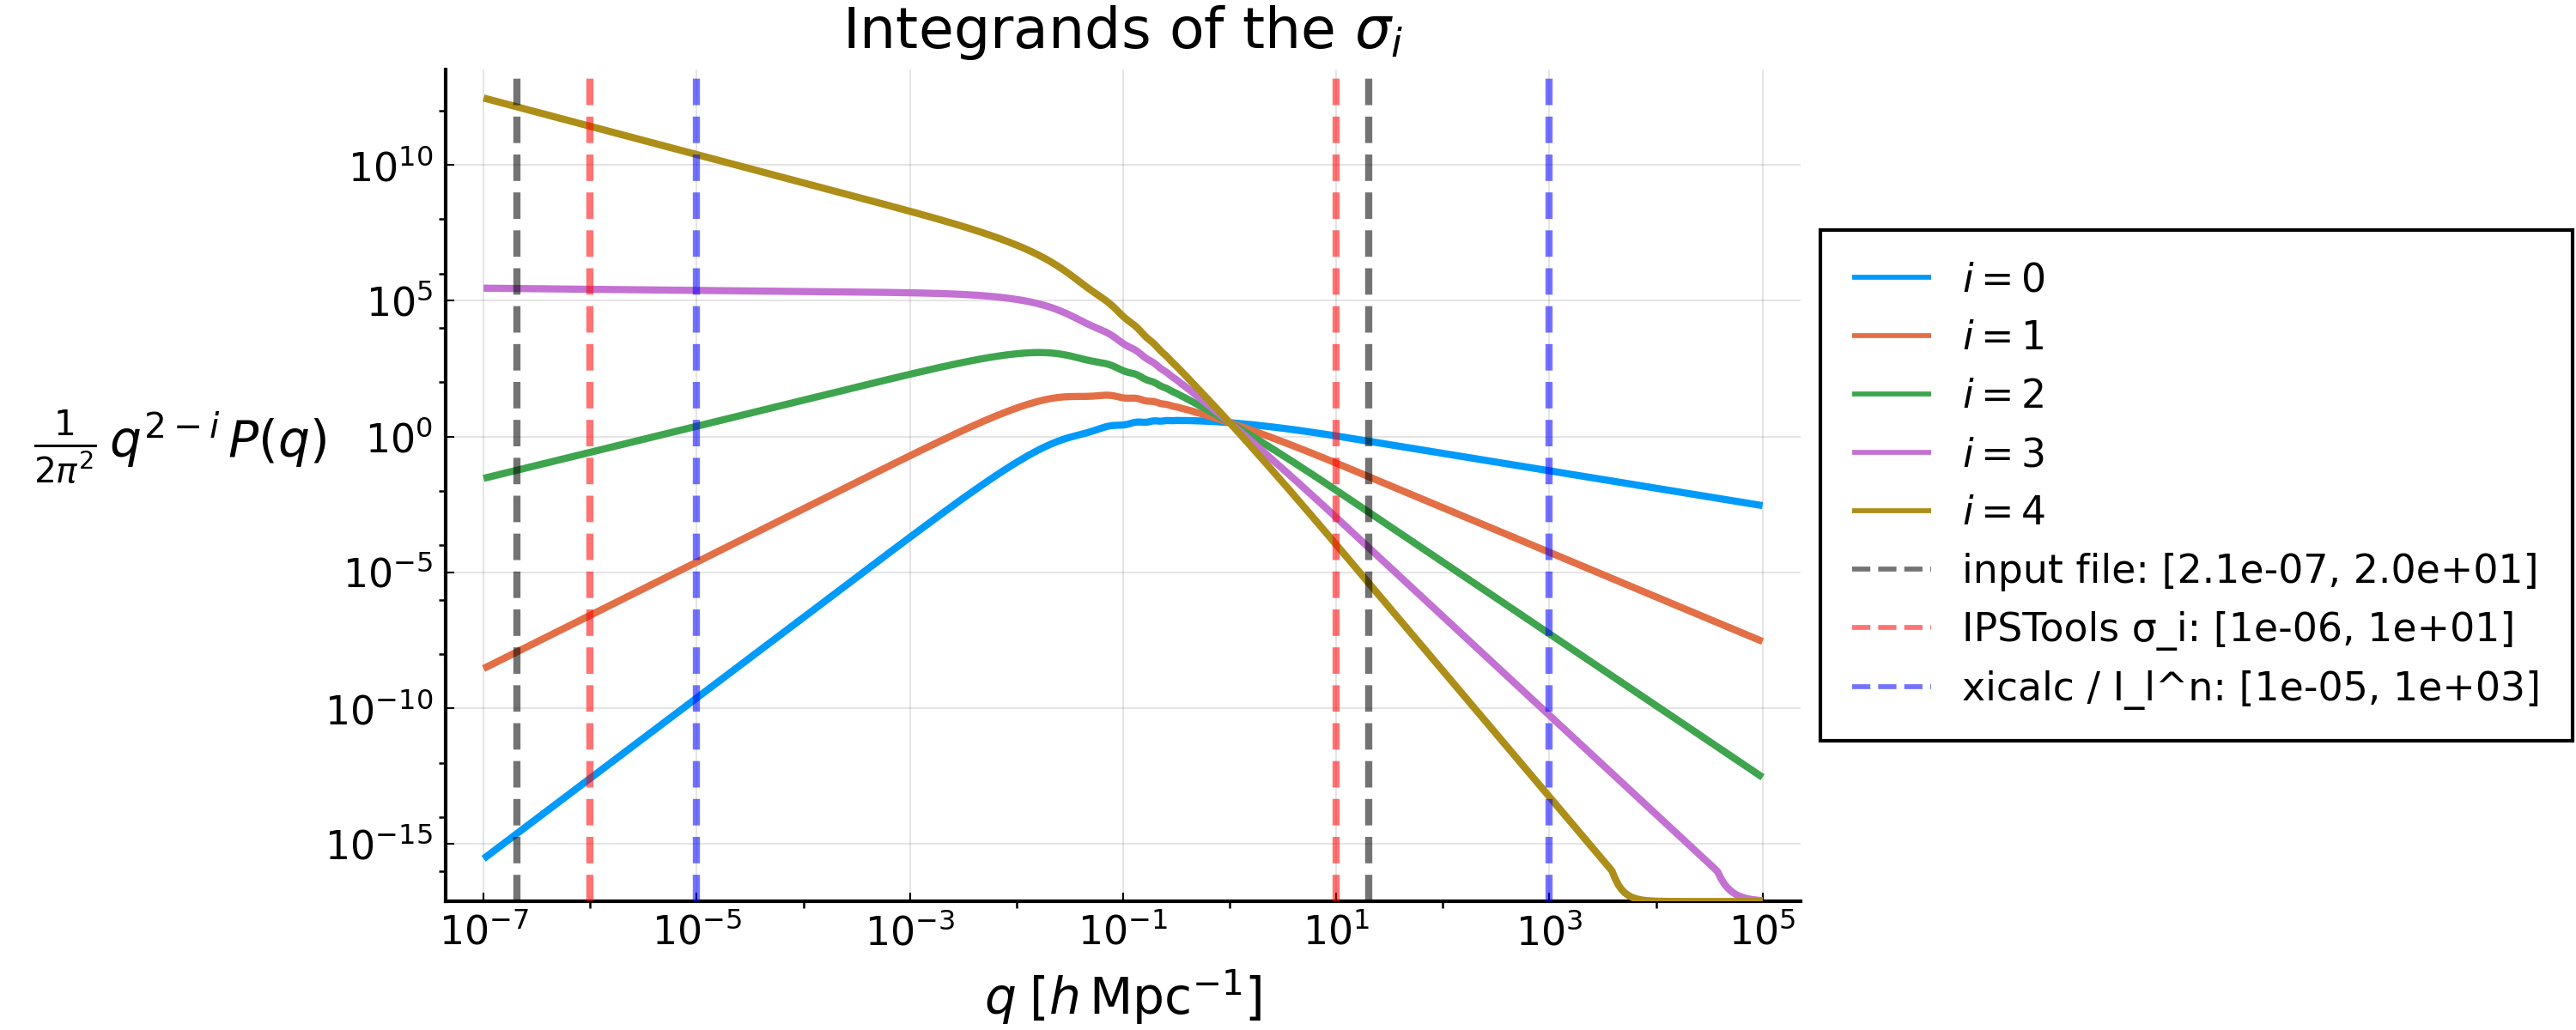

In [45]:
plot_integrands(
    IS=IS, qs=10 .^ range(-7, 5, length=400), 
    r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n",
    left_margin=10Plots.mm, 
    yticksmin=1e-15, yticksmax=1e20, yticksstep=5,
    xticksmin=1e-7, xticksmax=1e5, xticksstep=2,
)

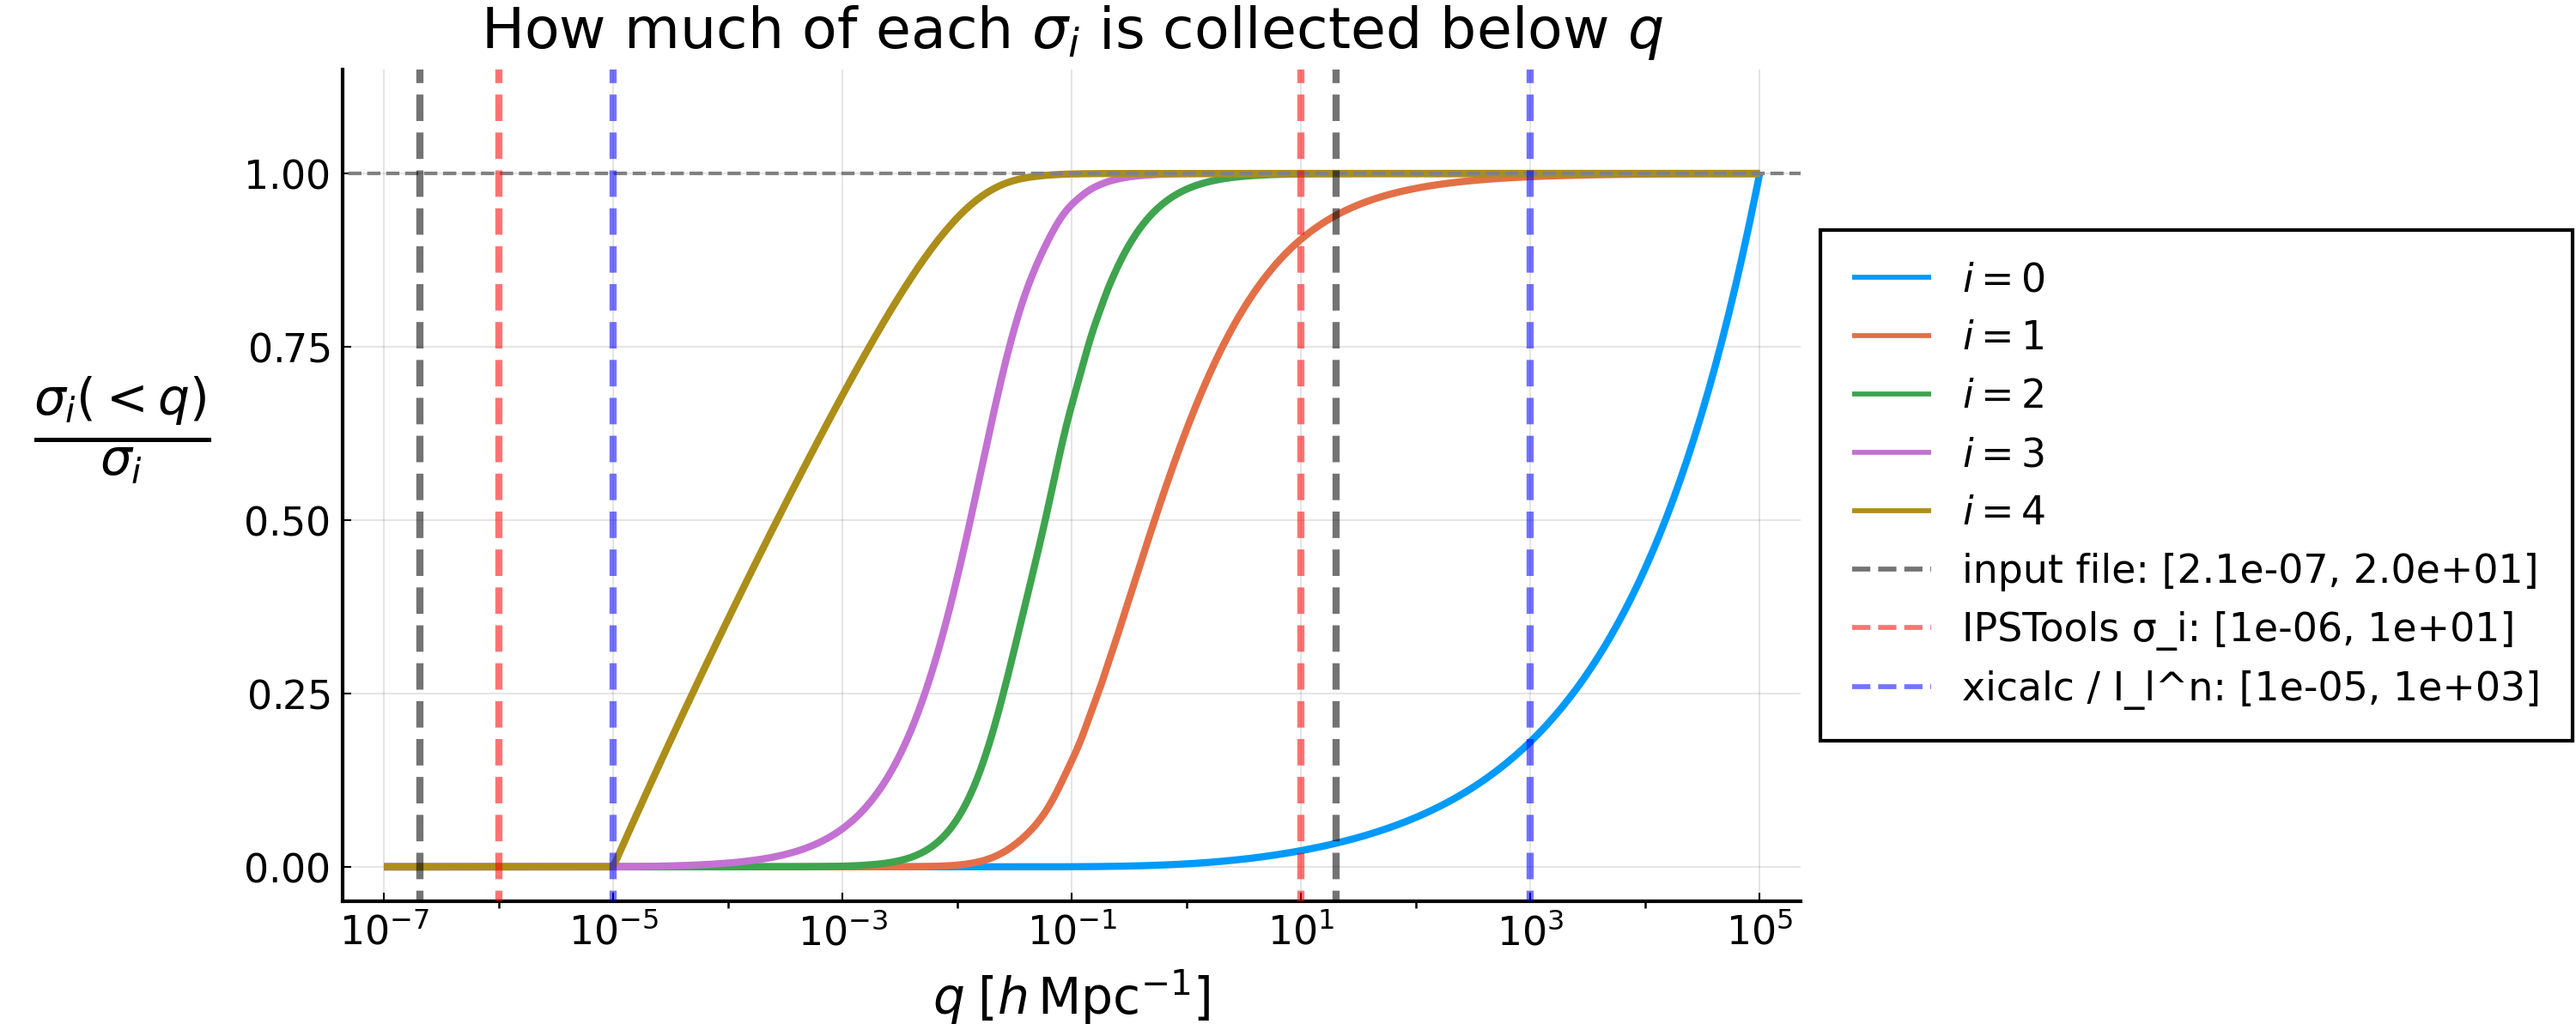

In [47]:
plot_cumulatives(
    IS=IS, qs=10 .^ range(-7, 5, length=400), 
    r1=KS_DATA, l1="input file", r2=KS_IPSTOOLS, l2="IPSTools σ_i", r3=KS_XICALC, l3="xicalc / I_l^n",
    yguidefontrotation=-90, left_margin=10Plots.mm, 
    title="How much of each " * L"\sigma_i" * " is collected below " * L"q",
    xlabel=L"q \; [h \, \mathrm{Mpc}^{-1}]",
    ylabel=L"\frac{\sigma_i(<q)}{\sigma_i}" *  " "^10,
    ylabelfontsize=20,
    xticksmin=1e-7, xticksmax=1e5, xticksstep=2,
)

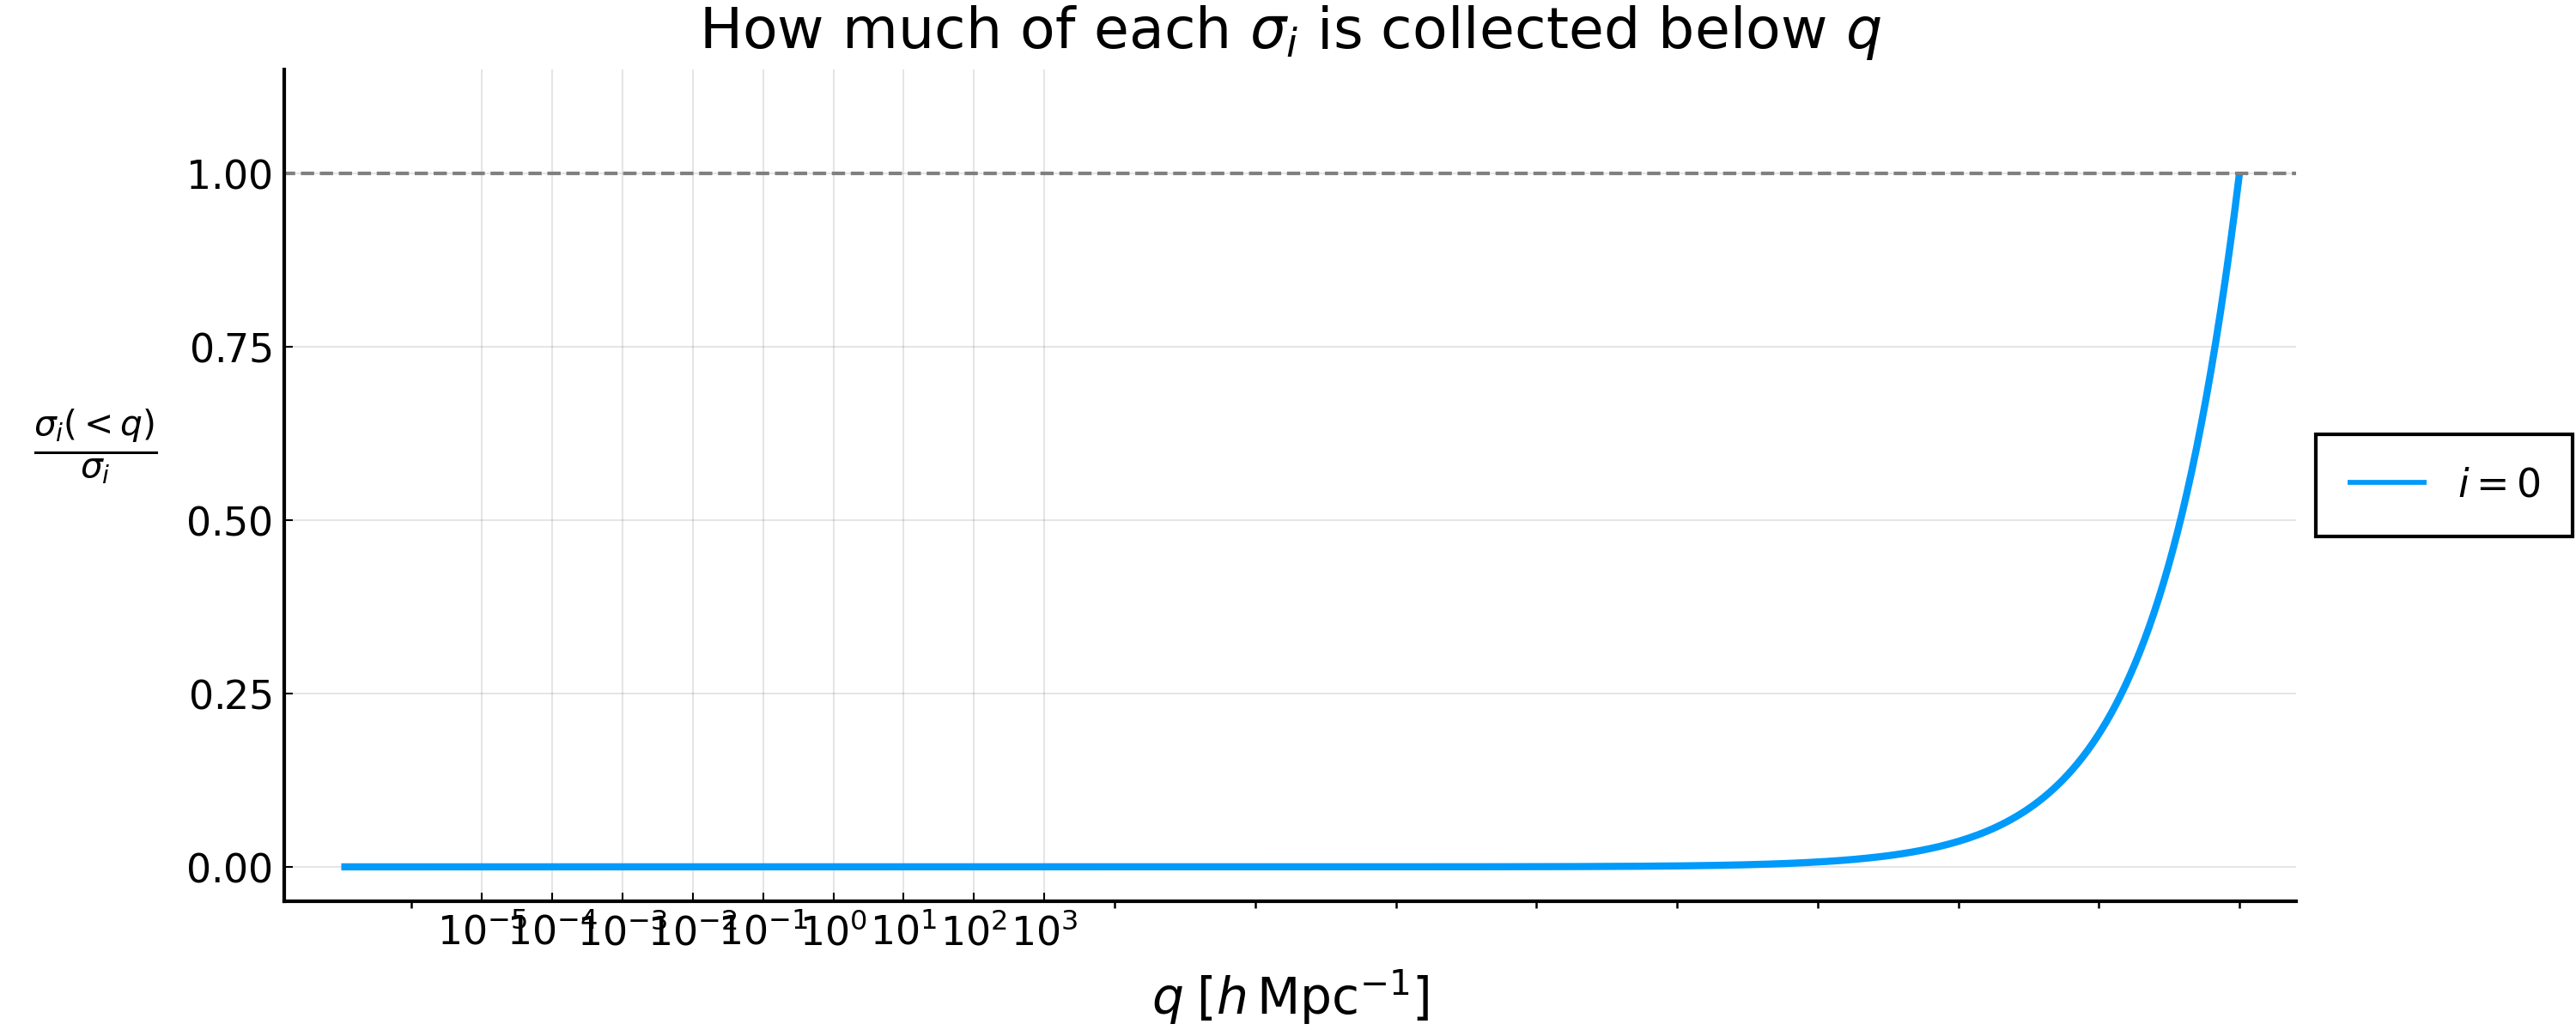

In [25]:
plot_cumulatives(
    IS=[0], qs=10 .^ range(-7, 20, length=400), 
    r1=nothing, r2=nothing, r3=nothing
)

## Convergence tables

`k_max` is scanned at fixed `k_min` and vice versa. Note that the input file is
only tabulated up to `k ≈ 20`: past that, `P(q)` is the power-law extrapolation of
`InputPS`, so most of `σ_0` computed to `k_max = 1e3` comes from extrapolated data.

In [26]:
convergence_table(
    IS=IS,
    kmins=[1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3],
    kmaxs=[1e0, 1e1, 2e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8],
    KMIN=KS_XICALC[1],
    KMAX=KS_IPSTOOLS[2],
    io=stdout
)


### sigma_i as a function of k_max   (k_min = 1.0e-5 fixed)

k_max                 sigma_0                    sigma_1                    sigma_2                    sigma_3                    sigma_4                    
1.0e+00  |  3.413918e+00   0.00036% |  1.097115e+01   0.63020% |  9.882776e+01   0.97788% |  3.731320e+03   0.99963% |  1.491559e+06   1.00000% |
1.0e+01  |  1.858428e+01   0.00194% |  1.575556e+01   0.90502% |  1.010636e+02   1.00000% |  3.732686e+03   1.00000% |  1.491560e+06   1.00000% |
2.0e+01  |  2.692211e+01   0.00281% |  1.634863e+01   0.93909% |  1.011075e+02   1.00043% |  3.732689e+03   1.00000% |  1.491560e+06   1.00000% |
1.0e+02  |  5.654162e+01   0.00589% |  1.703120e+01   0.97830% |  1.011267e+02   1.00062% |  3.732690e+03   1.00000% |  1.491560e+06   1.00000% |
1.0e+03  |  1.432850e+02   0.01493% |  1.732273e+01   0.99504% |  1.011282e+02   1.00064% |  3.732690e+03   1.00000% |  1.491560e+06   1.00000% |
1.0e+04  |  3.414843e+02   0.03559% |  1.738935e+0

## Your own extremes

Edit the two numbers below to try any range you like.

In [27]:
my_sigmas(1e-5, 1e3)


### sigma_i over [1.000e-05, 1.000e+03]

sigma_i          your range         IPSTools        ratio
sigma_0        1.432850e+02     1.858428e+01       7.7100
sigma_1        1.732273e+01     1.575556e+01       1.0995
sigma_2        1.011282e+02     1.010636e+02       1.0006
sigma_3        3.732690e+03     3.734929e+03       0.9994
sigma_4        1.491560e+06     2.074924e+06       0.7189


## Save the plots and the data

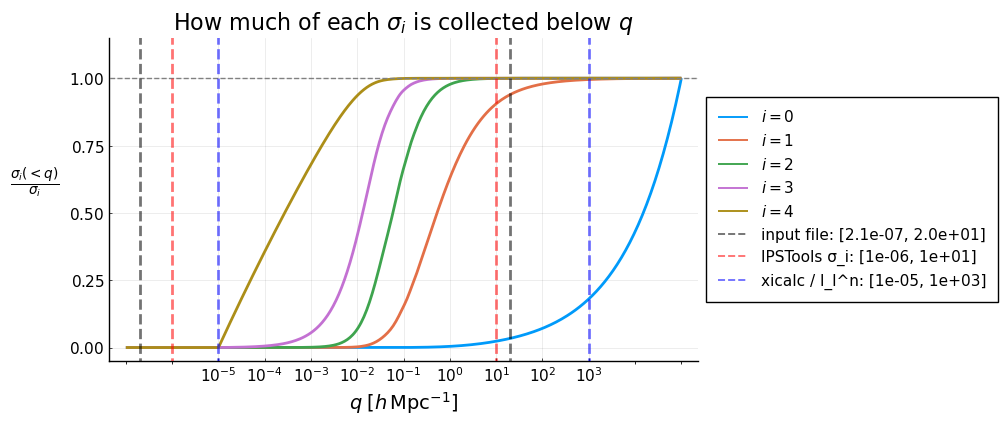

In [28]:
save_plot(plot_integrands(), "sigma_i_integrands.png");
save_plot(plot_cumulatives(), "sigma_i_cumulatives.png");
save_data();

## END